In [3]:
cd ..

c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


c:\Users\Lenovo\Desktop\FYP\Tourist-Attraction-Recommendation-System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
model = "distilbert-base-uncased"
# Load the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model)
# Load the model
model = DistilBertModel.from_pretrained(model)

In [9]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [10]:
attraction_df = pd.read_csv("./Data/FinalDataset/places.csv")
ratings_df = pd.read_csv("./Data/FinalDataset/ratings.csv")
ratings_df.head()


,user_id,place_id,rating
0,9,6175,5
1,10,6175,5
2,11,6175,5
3,12,6175,5
4,13,6175,4


In [11]:
# Rename the 'id' column to 'place_id'
attraction_df.rename(columns={'id': 'place_id'}, inplace=True)
attraction_df.head()

,place_id,name,address,latitude,longitude,location,types,description
0,1,\tChapat Ganesh Mandir,NaN,27.671314,85.328967,0,NaN,Religious Site Chapat Ganesh Temple is Ganesh ...
1,2,Mayadevi Temple,NaN,27.469641,83.275785,0,NaN,Religious Site The Mayadevi temple is situated...
2,3,Sikali Mandir,NaN,27.643535,85.285502,0,NaN,Religious Site Sikali Temple lies in the south...
3,4,'D DECORE AQUARIUM HOUSE,"JG96+7HX, sauraha Sauraha chock, rata‍nanagara...",27.618242,84.511491,sauraha Sauraha chock,aquarium,'D DECORE AQUARIUM HOUSE is a well-known locat...
4,5,( baalagaurau shadaananadakao shaalaiika) Stat...,"944P+RR2, shadaananada 57000, naepaala",27.357001,87.137018,shadaananada,monument,( baalagaurau shadaananadakao shaalaiika) Stat...


In [12]:
# Add a new column 'attractionID'
attraction_df['attractionID'] = range(1, len(attraction_df) + 1)
attraction_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   place_id      6475 non-null   int64  
 1   name          6475 non-null   object 
 2   address       6100 non-null   object 
 3   latitude      6475 non-null   float64
 4   longitude     6475 non-null   float64
 5   location      6430 non-null   object 
 6   types         5516 non-null   object 
 7   description   6475 non-null   object 
 8   attractionID  6475 non-null   int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 455.4+ KB


In [13]:
# Check if a GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(device)

cuda


In [14]:
def generate_embeddings(text):
    # Tokenize the input text and move the input tensors to the device
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
    
    with torch.no_grad():
        # Pass the inputs through the model
        outputs = model(**inputs)
    
    # Generate embeddings using mean pooling over token embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    
    # Optionally move the embeddings back to the CPU
    embeddings = embeddings.cpu().numpy()
    # Debug: Print the shape of the embeddings
    print(f"Generated embeddings shape: {embeddings.shape}")

    return embeddings

                        

In [15]:
# Fill null values in the 'description' column with an empty string
attraction_df['description'] = attraction_df['description'].fillna('')

# Apply the generate_embeddings function to the 'description' column
attraction_df['Embeddings'] = attraction_df['description'].apply(generate_embeddings)


Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings shape: (768,)
Generated embeddings

In [16]:
def custom_cosine_similarity(vector_a, vector_b):
    # Ensure the vectors are numpy arrays
    vector_a = np.array(vector_a)
    vector_b = np.array(vector_b)
    
    # Calculate the dot product and magnitudes
    dot_product = np.dot(vector_a, vector_b)
    magnitude_a = np.linalg.norm(vector_a)
    magnitude_b = np.linalg.norm(vector_b)
    
    # Avoid division by zero
    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0
    
    # Compute cosine similarity
    similarity = dot_product / (magnitude_a * magnitude_b)
    return similarity

In [17]:
attraction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6475 entries, 0 to 6474
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   place_id      6475 non-null   int64  
 1   name          6475 non-null   object 
 2   address       6100 non-null   object 
 3   latitude      6475 non-null   float64
 4   longitude     6475 non-null   float64
 5   location      6430 non-null   object 
 6   types         5516 non-null   object 
 7   description   6475 non-null   object 
 8   attractionID  6475 non-null   int64  
 9   Embeddings    6475 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 506.0+ KB


In [18]:
# 2. User Profile Construction
def build_user_profile(user_id):
    user_ratings = ratings_df[ratings_df['user_id'] == user_id]
    high_rated_places = user_ratings[user_ratings['rating'] >= 4]
    if high_rated_places.empty:
        return None
    
    # Convert embeddings to NumPy arrays
    place_embeddings = np.array(attraction_df[attraction_df['place_id'].isin(high_rated_places['place_id'])]['Embeddings'].tolist())
    
    # Average the embeddings to form the user profile
    user_profile = place_embeddings.mean(axis=0)
    return user_profile


In [19]:
# 3. Recommendation
def recommend_places(user_id, top_n=5):
    user_profile = build_user_profile(user_id)
    # print(user_profile.shape)
    if user_profile is None:
        return pd.DataFrame(columns=['place_id', 'description', 'similarity'])
    # Calculate similarity between user profile and all attraction embeddings
    similarities = cosine_similarity([user_profile], attraction_df['Embeddings'].tolist()).flatten()
    attraction_df['similarity'] = similarities

    # Sort the attractions by similarity and get top_n recommendations
    recommended_places = attraction_df.sort_values(by='similarity', ascending=False).head(top_n)
    
    return recommended_places[['place_id', 'name' ,'description', 'similarity']]


In [23]:
# Drop rows with NaN values in the 'place_id' column
ratings_df.dropna(subset=['place_id'], inplace=True)

# Convert 'place_id' column to integers
ratings_df['place_id'] = ratings_df['place_id'].astype(int)

user_id = 13
recommend_places(user_id,10)

,place_id,name,description,similarity
4698,4699,baraahaa thaana,"baraahaa thaana is a well-known location, loca...",0.988538
5502,5503,latainaatha maanadaaum,latainaatha maanadaaum is a well-known locatio...,0.988074
6474,6475,"🕉️ Baachalaa Thaan , Achham, ramaroshan","🕉️ Baachalaa Thaan , Achham, ramaroshan is a w...",0.986922
4156,4157,Tanjakot Temple,"Tanjakot Temple is a well-known location, loca...",0.986599
5397,5398,kaushaenaii (tairatha sathala),kaushaenaii (tairatha sathala) is a well-known...,0.986133
5748,5749,nayaaँ manadaira,"nayaaँ manadaira is a well-known location, loc...",0.985965
3785,3786,Shivalaya Tample shaiwaalaya manadaira,Shivalaya Tample shaiwaalaya manadaira is a we...,0.985860
5565,5566,mahaadaewa manadaira galachhaii,mahaadaewa manadaira galachhaii is a well-know...,0.985682
511,512,Bhajani word 8 Godchaura kailali,Bhajani word 8 Godchaura kailali is a well-kno...,0.985588
6185,6186,shaiwa daaँdaa rauwai bhayaalaii,shaiwa daaँdaa rauwai bhayaalaii is a well-kno...,0.985466


In [21]:
print(attraction_df['Embeddings'].head())


0    [-0.053229634, 0.12624575, 0.027391063, -0.060...
1    [-0.13549657, 0.07388258, -0.06519881, -0.2147...
2    [-0.1111075, 0.12172582, -0.011140166, -0.2895...
3    [0.071489036, -0.0039467434, 0.17595606, -0.10...
4    [0.052710235, 0.28839037, 0.08137829, -0.21091...
Name: Embeddings, dtype: object


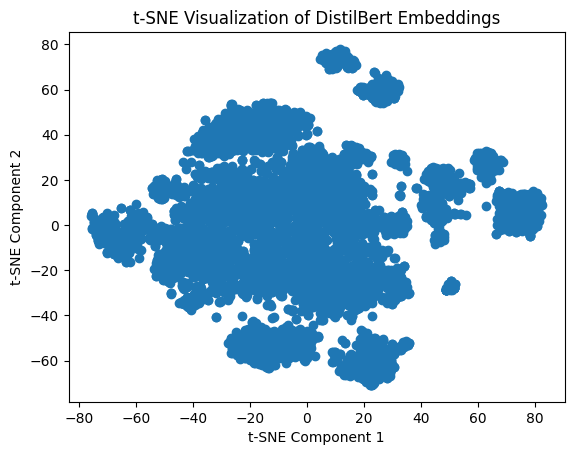

In [22]:

def visualize_embeddings_tsne(place_embeddings):
    # Convert the Series of lists to a 2D numpy array
    place_embeddings = np.vstack(place_embeddings)
    
    # Perform t-SNE to reduce to 2D
    tsne = TSNE(n_components=2, random_state=0)
    reduced_embeddings = tsne.fit_transform(place_embeddings)
    
    # Plot the 2D projections of the embeddings
    plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])
    plt.title("t-SNE Visualization of DistilBert Embeddings")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.show()

# Example usage with your attraction embeddings
visualize_embeddings_tsne(attraction_df['Embeddings'])
